In [1]:
from functions import error_metrics, run_tft_tftorch
from ax import Client, RangeParameterConfig, ChoiceParameterConfig
import pandas as pd
from pathlib import Path
import csv
import numpy as np
import torch
from datetime import datetime
import matplotlib.pyplot as plt
from pytorch_forecasting import Baseline


In [3]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
deleted_sample = 0
test_size    = 8
target_col   = "FE"
# Load data
df = pd.read_csv("weekly_chile_data.csv")
df["FECHA"] = pd.to_datetime(df["FECHA"])
df = df.sort_values("FECHA")
df = df.rename(columns=lambda x: x.replace(".", "_"))

# Preprocess
tmp = df.copy()
tmp = tmp.sort_values("FECHA").copy()
tmp["series"] = "kz"
tmp["time_idx"] = tmp.groupby("series").cumcount()
tmp["dow"] = tmp["FECHA"].dt.weekday.astype(int)
tmp["month"] = tmp["FECHA"].dt.month.astype(int)
if deleted_sample > 0:
    tmp = tmp.iloc[:-deleted_sample]
train_cut = tmp["time_idx"].max() - test_size

In [4]:
train_mask = tmp["time_idx"] <= train_cut
mu = tmp.loc[train_mask, target_col].mean()
sigma = tmp.loc[train_mask, target_col].std()

tmp["target_scaled"] = (tmp[target_col] - mu) / sigma
tmp2 = tmp.drop(columns=[target_col])

In [5]:
y_true_scaled, y_pred_scaled, tft, train_loader, val_loader, training = run_tft_tftorch(
    data=tmp2,
    target_col="target_scaled",
    window_size=26,
    test_size=test_size,
    grad_clip=None,
    d_model=64,
    n_head=4,
    num_layers=2,
    epoch_number=100,
    lr=3e-3,
    batch_size=8,
    seed=1000000,
    train_cut=train_cut,
)

Seed set to 1000000


num train samples: 322
num val samples: 1
num train batches: 41


Epoch 1/100 [train]:   0%|          | 0/41 [00:00<?, ?it/s]

Epoch 1/100 | train_loss=0.8692 | val_loss=0.4340


Epoch 2/100 [train]:   0%|          | 0/41 [00:00<?, ?it/s]

...

Epoch 98/100 | train_loss=0.0622 | val_loss=0.3486


Epoch 99/100 [train]:   0%|          | 0/41 [00:00<?, ?it/s]

Epoch 99/100 | train_loss=0.3231 | val_loss=0.3111


Epoch 100/100 [train]:   0%|          | 0/41 [00:00<?, ?it/s]

Epoch 100/100 | train_loss=0.1932 | val_loss=0.1255
sample targets: tensor([ 0.1753,  0.0468, -0.0541, -0.1705, -0.1644, -0.1867, -0.2064, -0.1830])


In [6]:
#baseline metrics
y_pred_baseline = tmp[target_col].mean()
y_true = tmp.loc[~train_mask, target_col].to_numpy()
y_pred_baseline_arr = np.full_like(y_true, y_pred_baseline)
error_metrics(y_true, y_pred_baseline_arr)

MSE: 59455.01
RMSE: 243.83
MAE: 224.46
MAPE: 12.45%
R²: -2.5306


(np.float64(224.45745634287377),
 np.float64(12.447806184417974),
 np.float64(59455.01001203609),
 np.float64(243.83398042938168),
 np.float64(-2.530613888785798))

In [7]:
y_pred = y_pred_scaled * sigma + mu
y_true = y_true_scaled * sigma + mu

In [8]:
error_metrics(y_true, y_pred)

MSE: 24030.67
RMSE: 155.02
MAE: 139.15
MAPE: 7.42%
R²: -0.4270


(np.float64(139.1473763665112),
 np.float64(7.423152028789366),
 np.float64(24030.671190670873),
 np.float64(155.0182930839805),
 np.float64(-0.42701214658700226))

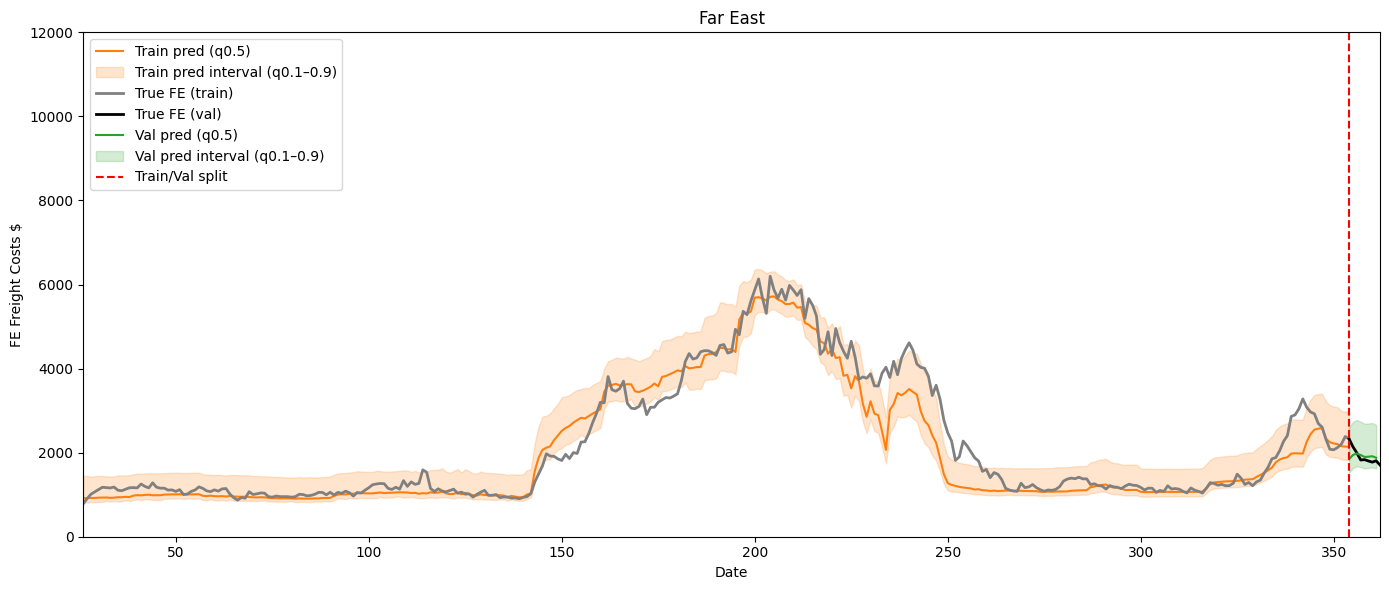

In [ ]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

tft.eval()
is_cuda = torch.cuda.is_available()
device = torch.device("cuda" if is_cuda else "cpu")
tft.to(device)

all_records = []

with torch.no_grad():
    for split_name, loader in [("train", train_loader), ("val", val_loader)]:
        for batch in loader:
            # move to device
            if is_cuda:
                for k in list(batch.keys()):
                    batch[k] = batch[k].to(device)

            outputs = tft(batch)
            preds = outputs["predicted_quantiles"]  # [B, future_len, Q]

            # back to cpu numpy
            preds_np = preds.cpu().numpy()
            time_idx_np = batch["time_index"].cpu().numpy()  # [B]

            B, future_len, Q = preds_np.shape

            for b in range(B):
                base_t = int(time_idx_np[b])  # hist_end time_idx
                for h in range(future_len):
                    t_forecast = base_t + (h + 1)

                    q10_scaled = preds_np[b, h, 0]
                    q50_scaled = preds_np[b, h, 1]
                    q90_scaled = preds_np[b, h, 2]

                    # store in scaled space for now
                    all_records.append(
                        {
                            "time_idx": t_forecast,
                            "q10_scaled": q10_scaled,
                            "q50_scaled": q50_scaled,
                            "q90_scaled": q90_scaled,
                            "split": split_name,
                        }
                    )

# Build dataframe with all predictions
pred_df = pd.DataFrame(all_records)

# If multiple predictions per time_idx (overlapping windows), aggregate (e.g. mean)
pred_df = (
    pred_df.groupby(["time_idx", "split"], as_index=False)[["q10_scaled", "q50_scaled", "q90_scaled"]]
    .mean()
)

# Unscale quantiles
pred_df["q10"] = pred_df["q10_scaled"] * sigma + mu
pred_df["q50"] = pred_df["q50_scaled"] * sigma + mu
pred_df["q90"] = pred_df["q90_scaled"] * sigma + mu
# Map time_idx -> FECHA (assuming single series)
time_map = tmp[["time_idx", "FECHA"]].drop_duplicates()
pred_df = pred_df.merge(time_map, on="time_idx", how="left")
plt.figure(figsize=(14, 6))

# x-axis: choose either 'time_idx' or 'FECHA'
x_full = tmp["time_idx"]  # or tmp["FECHA"]
y_full = tmp["FE"]        # true values (unscaled)



# 2) Train predictions (median + interval)
train_mask = pred_df["split"] == "train"
x_train = pred_df.loc[train_mask, "time_idx"]
y_train_med = pred_df.loc[train_mask, "q50"]
y_train_low = pred_df.loc[train_mask, "q10"]
y_train_high = pred_df.loc[train_mask, "q90"]

plt.plot(x_train, y_train_med, label="Train pred (q0.5)", linewidth=1.5, color="tab:orange")
plt.fill_between(
    x_train,
    y_train_low,
    y_train_high,
    alpha=0.2,
    color="tab:orange",
    label="Train pred interval (q0.1–0.9)",
)

# 3) Validation predictions (median + interval), different color
val_mask = pred_df["split"] == "val"
x_val = pred_df.loc[val_mask, "time_idx"]
y_val_med = pred_df.loc[val_mask, "q50"]
y_val_low = pred_df.loc[val_mask, "q10"]
y_val_high = pred_df.loc[val_mask, "q90"]
y_diff_med = y_train_med.iloc[-1] - y_val_med.iloc[0]
y_diff_low = y_train_low.iloc[-1] - y_val_low.iloc[0]
y_diff_high = y_train_high.iloc[-1] - y_val_high.iloc[0]
train_cutoff = x_val.iloc[0]  # First validation time_idx
train_true_mask = tmp["time_idx"] <= train_cutoff
plt.plot(tmp.loc[train_true_mask, "time_idx"],
         tmp.loc[train_true_mask, "FE"],
         label="True FE (train)", linewidth=2, color="gray")
val_true_mask = tmp["time_idx"] >= train_cutoff
plt.plot(tmp.loc[val_true_mask, "time_idx"],
         tmp.loc[val_true_mask, "FE"],
         label="True FE (val)", linewidth=2, color="black")
plt.plot(x_val, y_val_med, label="Val pred (q0.5)", linewidth=1.5, color="tab:green")
plt.fill_between(
    x_val,
    y_val_low,
    y_val_high,
    alpha=0.2,
    color="tab:green",
    label="Val pred interval (q0.1–0.9)",
)
plt.plot([x_val.iloc[0],x_val.iloc[0]], [0,15000], linestyle='--', color='red', label='Train/Val split')
plt.xlabel("Date")   # or "Date"
plt.ylabel("FE Freight Costs $")
plt.title("Far East")
plt.xlim(26, tmp["time_idx"].max())
plt.ylim(0, 12000)
plt.legend()
plt.tight_layout()
plt.show()


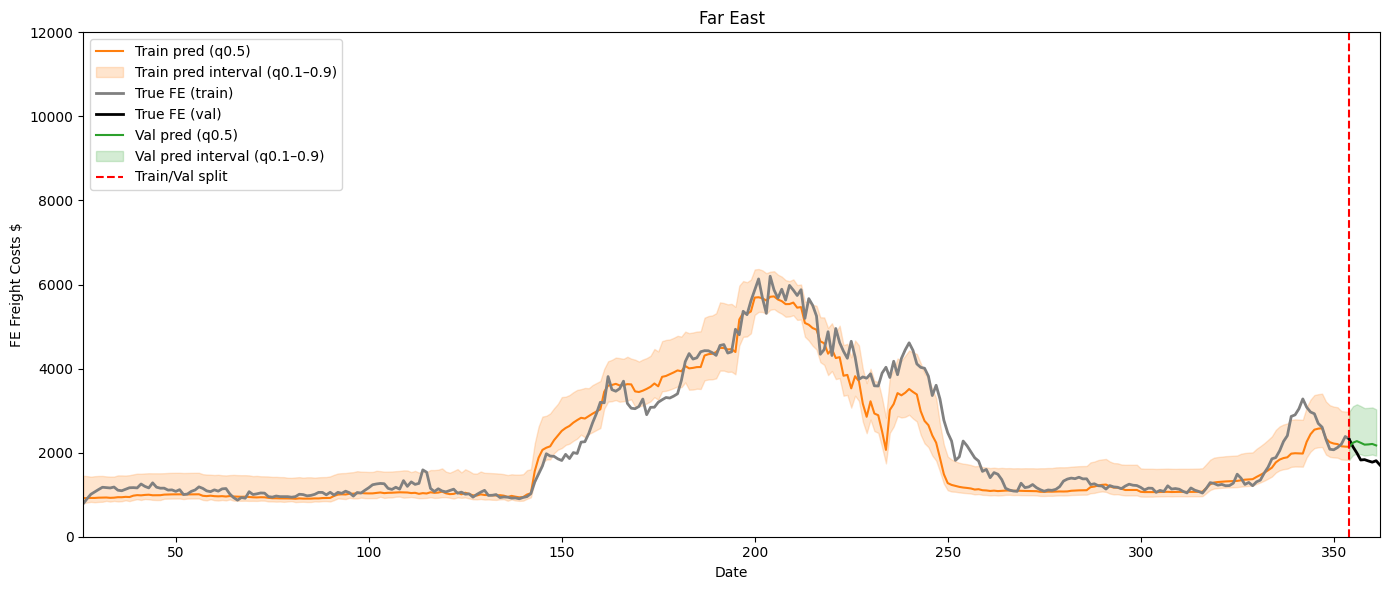

In [10]:
plt.figure(figsize=(14, 6))
plt.plot(x_train, y_train_med, label="Train pred (q0.5)", linewidth=1.5, color="tab:orange")
plt.fill_between(
    x_train,
    y_train_low,
    y_train_high,
    alpha=0.2,
    color="tab:orange",
    label="Train pred interval (q0.1–0.9)",
)
y_val_med += y_diff_med
y_val_low += y_diff_low
y_val_high += y_diff_high
train_cutoff = x_val.iloc[0]  # First validation time_idx
train_true_mask = tmp["time_idx"] <= train_cutoff
plt.plot(tmp.loc[train_true_mask, "time_idx"],
         tmp.loc[train_true_mask, "FE"],
         label="True FE (train)", linewidth=2, color="gray")
val_true_mask = tmp["time_idx"] >= train_cutoff
plt.plot(tmp.loc[val_true_mask, "time_idx"],
         tmp.loc[val_true_mask, "FE"],
         label="True FE (val)", linewidth=2, color="black")
plt.plot(x_val, y_val_med, label="Val pred (q0.5)", linewidth=1.5, color="tab:green")
plt.fill_between(
    x_val,
    y_val_low,
    y_val_high,
    alpha=0.2,
    color="tab:green",
    label="Val pred interval (q0.1–0.9)",
)
plt.plot([x_val.iloc[0],x_val.iloc[0]], [0,15000], linestyle='--', color='red', label='Train/Val split')
plt.xlabel("Date")   # or "Date"
plt.ylabel("FE Freight Costs $")
plt.title("Far East")
plt.xlim(26, tmp["time_idx"].max())
plt.ylim(0, 12000)
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
error_metrics(y_true, y_val_med)

MSE: 140997.72
RMSE: 375.50
MAE: 346.36
MAPE: 19.19%
R²: -7.3729


(np.float64(346.3571034293524),
 np.float64(19.190564665990177),
 np.float64(140997.71742290963),
 np.float64(375.49662771176736),
 np.float64(-7.37286040856176))

In [12]:
y_diff_med

np.float32(292.45398)

In [9]:
pred_tr_high

array([[5101.64797777, 4932.99430907, 3911.21632532, 3613.29861016,
        3710.61353228, 3769.57463502, 3789.86201535, 4125.83527482],
       [2122.6297477 , 1995.60464596, 1960.38330919, 1950.09285817,
        1954.026762  , 1952.28797271, 1962.0111861 , 1969.70597043],
       [2924.63624811, 3065.12864844, 3049.64987453, 2462.49809166,
        2400.59535483, 2381.82375067, 2376.81637341, 2375.5426239 ],
       [2031.75067512, 2181.79136418, 2293.68564   , 2397.94296438,
        2429.11615756, 2460.7303067 , 2478.46392938, 2639.23253959],
       [4511.22570557, 4584.31635287, 4745.02049525, 4835.04524539,
        4896.66606671, 5105.40061907, 5369.67195332, 5544.17983514],
       [2478.14846287, 2461.84228258, 2641.88334558, 2824.50803335,
        2935.30760394, 2979.81943736, 3574.29199216, 3956.00551893],
       [1861.09169071, 1693.33956144, 1712.85823973, 1755.62161863,
        1817.02113013, 1847.22986091, 1879.25945615, 1901.57946438],
       [7226.35532833, 7111.71818925, 663

In [10]:
pred_tr_med_scaled.shape

(8, 8)

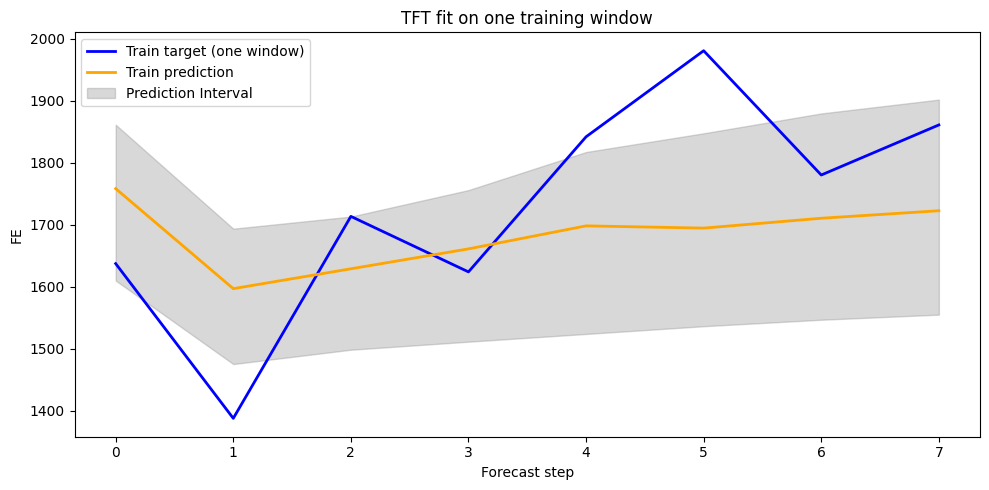

In [21]:
import matplotlib.pyplot as plt
import numpy as np
b = 6   # first sample in the batch
y_tr_scaled_1 = y_tr_scaled[b]
pred_tr_med_scaled_1 = pred_tr_med_scaled[b]
pred_tr_low_scaled_1 = pred_tr_low_scaled[b]
pred_tr_high_scaled_1 = pred_tr_high_scaled[b]

# unscale
y_tr_1 = y_tr_scaled_1 * sigma + mu
pred_tr_med_1 = pred_tr_med_scaled_1 * sigma + mu
pred_tr_low_1 = pred_tr_low_scaled_1 * sigma + mu
pred_tr_high_1 = pred_tr_high_scaled_1 * sigma + mu

steps = np.arange(len(y_tr_1))

plt.figure(figsize=(10,5))
plt.plot(steps, y_tr_1, label="Train target (one window)", linewidth=2, color='blue')
plt.plot(steps, pred_tr_med_1, label="Train prediction", linewidth=2, color='orange')
plt.fill_between(steps, pred_tr_low_1, pred_tr_high_1, color='gray', alpha=0.3, label='Prediction Interval')
plt.xlabel("Forecast step")
plt.ylabel("FE")
plt.title("TFT fit on one training window")
plt.legend()
plt.tight_layout()
plt.show()


In [14]:
tft.eval()
with torch.no_grad():
    batch_val = next(iter(val_loader))
    if torch.cuda.is_available():
        for k in list(batch_val.keys()):
            batch_val[k] = batch_val[k].to(tft.device)  # or same device you used

    outputs = tft(batch_val)
    pred_all_q = outputs["predicted_quantiles"].cpu().numpy()   # [B, future_len, Q]
    y_true_scaled = batch_val["target"].cpu().numpy()           # [B, future_len]


In [15]:
b = 0
y_pred_scaled = pred_all_q[b, :, 1]         # median quantile
y_true_scaled_1 = y_true_scaled[b]

y_pred = y_pred_scaled * sigma + mu
y_true = y_true_scaled_1 * sigma + mu


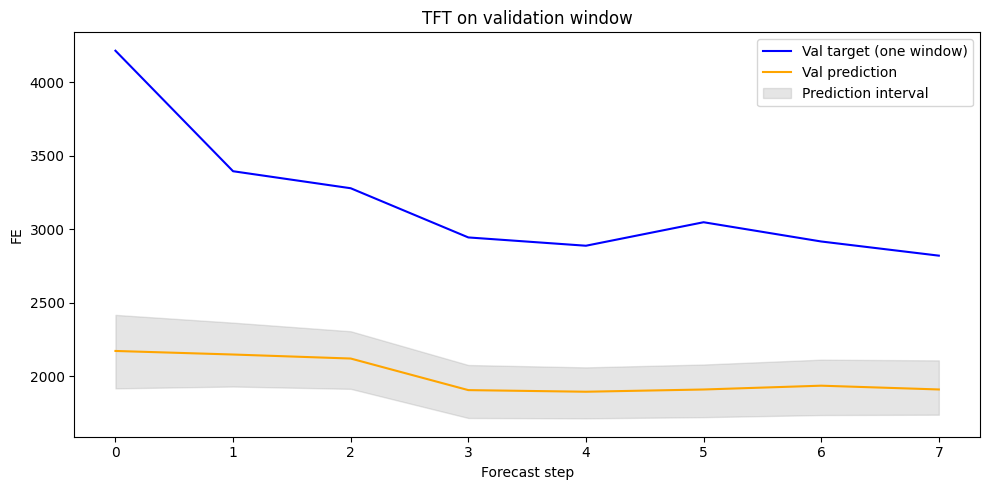

In [16]:
import numpy as np
steps = np.arange(len(y_true))

plt.figure(figsize=(10,5))
plt.plot(steps, y_true, label="Val target (one window)", color="blue")
plt.plot(steps, y_pred, label="Val prediction", color="orange")
plt.fill_between(
    steps,
    (pred_all_q[b, :, 0] * sigma + mu),   # q=0.1
    (pred_all_q[b, :, 2] * sigma + mu),   # q=0.9
    alpha=0.2,
    color="gray",
    label="Prediction interval"
)

plt.xlabel("Forecast step")
plt.ylabel("FE")
plt.title("TFT on validation window")
plt.legend()
plt.tight_layout()
plt.show()


In [13]:
y_pred = y_pred_scaled * sigma + mu
y_true = y_true_scaled * sigma + mu

In [14]:
y_pred

array([1765.17918561, 1802.59223198, 1828.46569938, 1852.42369943,
       1872.86731926, 1880.16157699, 1898.16664056, 1916.88222227,
       1936.55471415, 1885.49622764, 1904.80539012, 1923.51570141,
       1941.29545463, 1958.04319424, 1943.01525772, 1959.43623145,
       1976.3193549 , 1995.4850632 , 2021.19481825, 2048.47186369,
       2075.71794542, 2099.12831617, 2123.42658755, 2136.65632352])

In [15]:
y_true

array([[4630.61292319, 4725.98100445, 4760.68239531, 5445.00053257,
        5240.0984376 , 5010.97599519, 5067.18347365, 4635.90665605,
        4770.88797322, 3835.20653693, 3329.82151509, 3829.85615738,
        3458.57863653, 3462.92813087, 3757.12324387, 4215.95001571,
        3395.17485599, 3279.32235163, 2944.27631544, 2887.77282892,
        3047.81679527, 2916.6932564 , 2820.26026388, 2798.44979423]])

In [16]:
tft.eval()
with torch.no_grad():
    # assuming single series -> one sample in val_ds
    batch = next(iter(val_loader))
    print("sample targets:", batch["target"][0])
    outputs = tft(batch)
    pred_all_q = outputs["predicted_quantiles"].cpu().numpy()  # [B, future_len, Q]


sample targets: tensor([-0.0402, -0.0057,  0.0068,  0.2545,  0.1803,  0.0974,  0.1178, -0.0383,
         0.0105, -0.3281, -0.5110, -0.3300, -0.4644, -0.4628, -0.3564, -0.1903,
        -0.4873, -0.5293, -0.6505, -0.6710, -0.6130, -0.6605, -0.6954, -0.7033])


In [17]:
pred_all_q = pred_all_q * sigma + mu
pred_all_q

array([[[1474.9234626 , 1765.17918561, 1895.07751714],
        [1560.36812887, 1802.59223198, 1938.72612613],
        [1578.29479497, 1828.46569938, 1951.18144014],
        [1601.68227234, 1852.42369943, 1969.38414435],
        [1619.89189398, 1872.86731926, 1991.82162898],
        [1646.95976973, 1880.16157699, 1972.4518567 ],
        [1661.82794671, 1898.16664056, 1997.76270704],
        [1678.50848849, 1916.88222227, 2026.03717897],
        [1696.86864643, 1936.55471415, 2056.49459193],
        [1620.28289308, 1885.49622764, 1978.65777323],
        [1639.35488677, 1904.80539012, 2010.1445646 ],
        [1657.89094489, 1923.51570141, 2041.43700932],
        [1675.46581063, 1941.29545463, 2072.39445313],
        [1691.85944406, 1958.04319424, 2102.86438333],
        [1642.55172434, 1943.01525772, 2122.65974181],
        [1657.99075342, 1959.43623145, 2153.43832083],
        [1673.27166997, 1976.3193549 , 2184.08612762],
        [1689.9670348 , 1995.4850632 , 2216.17209957],
        [1

In [18]:
y_low = pred_all_q[:, :, 0][0]
y_med = pred_all_q[:, :, 1][0]
y_high = pred_all_q[:, :, 2][0]

In [19]:
metrics = error_metrics(y_true, y_med)

MSE: 4793397.57
RMSE: 2189.38
MAE: 1980.05
MAPE: 47.53%
R²: -5.5706


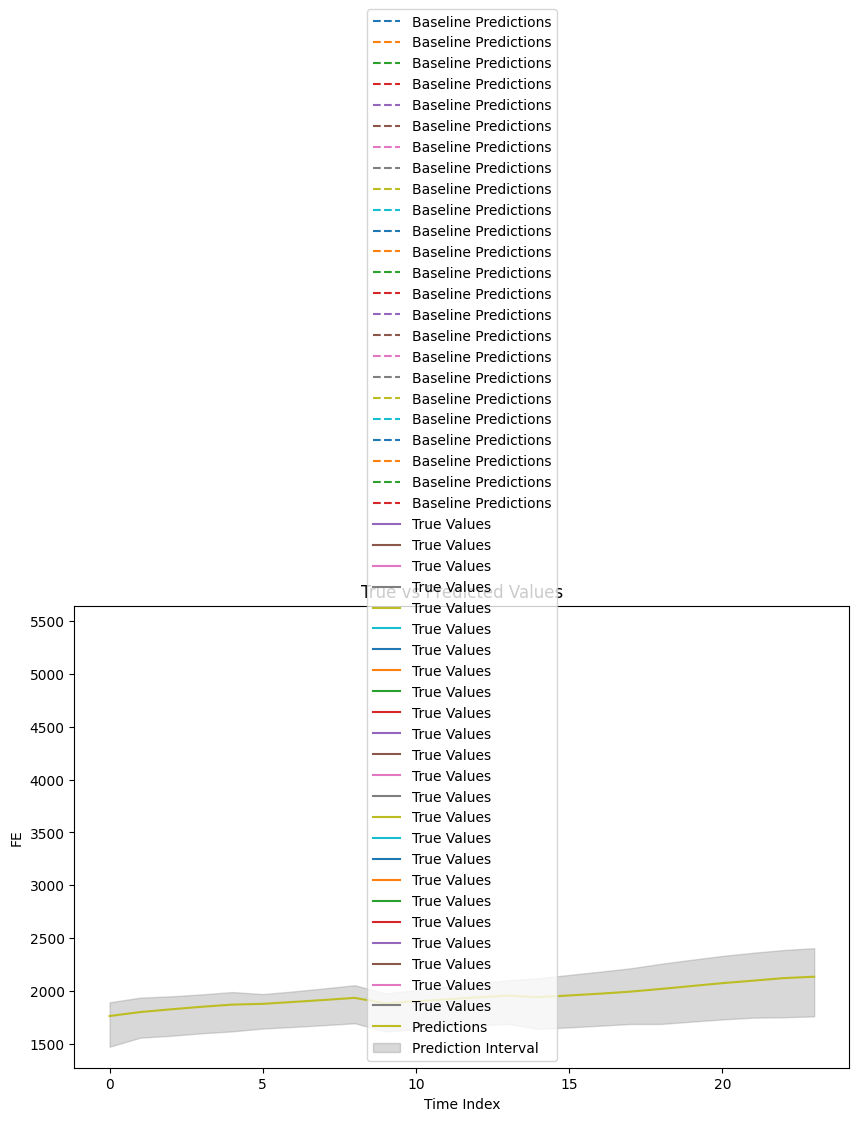

In [20]:
#plot y_true vs y_pred

plt.figure(figsize=(10, 6))
plt.plot([y_true[0] for _ in range(len(y_true))], label='Baseline Predictions', linestyle='--')
plt.plot(y_true, label='True Values')
plt.plot(y_med, label='Predictions')
plt.fill_between(range(len(y_med)), y_low, y_high, color='gray', alpha=0.3, label='Prediction Interval')
plt.xlabel('Time Index')
plt.ylabel(target_col)
plt.title('True vs Predicted Values')
plt.legend()
plt.show()